# Exploratory Data Analysis - Short Term Rental Prices
___

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import wandb

/home/fabiolima/miniconda3/envs/nyc_airbnb_dev/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/fabiolima/miniconda3/envs/nyc_airbnb_dev/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. Th

In [ ]:
run = wandb.init(project="nyc_airbnb", group="eda", save_code=True, job_type="eda")

# Download the data and fetch the artifact
artifact = run.use_artifact("sample.csv:latest")
artifact_local_path = artifact.file()

df = pd.read_csv(artifact_local_path)
df.head()

wandb: Currently logged in as: fabio_lima07 (fabio_lima07-mlops) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,9138664,Private Lg Room 15 min to Manhattan,47594947,Iris,Queens,Sunnyside,40.74271,-73.92493,Private room,74,2,6,2019-05-26,0.13,1,5
1,31444015,TIME SQUARE CHARMING ONE BED IN HELL'S KITCHEN...,8523790,Johlex,Manhattan,Hell's Kitchen,40.76682,-73.98878,Entire home/apt,170,3,0,NaN,NaN,1,188
2,8741020,Voted #1 Location Quintessential 1BR W Village...,45854238,John,Manhattan,West Village,40.73631,-74.00611,Entire home/apt,245,3,51,2018-09-19,1.12,1,0
3,34602077,Spacious 1 bedroom apartment 15min from Manhattan,261055465,Regan,Queens,Astoria,40.76424,-73.92351,Entire home/apt,125,3,1,2019-05-24,0.65,1,13
4,23203149,Big beautiful bedroom in huge Bushwick apartment,143460,Megan,Brooklyn,Bushwick,40.69839,-73.92044,Private room,65,2,8,2019-06-23,0.52,2,8


In [3]:
print(f"The shape of dataset is: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"The types of dataset are: \n{df.dtypes}")
print("The first 5 lines of the dataset: \n")
df.head()

The shape of dataset is: 20000 rows, 16 columns
The types of dataset are: 
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object
The first 5 lines of the dataset: 



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,9138664,Private Lg Room 15 min to Manhattan,47594947,Iris,Queens,Sunnyside,40.74271,-73.92493,Private room,74,2,6,2019-05-26,0.13,1,5
1,31444015,TIME SQUARE CHARMING ONE BED IN HELL'S KITCHEN...,8523790,Johlex,Manhattan,Hell's Kitchen,40.76682,-73.98878,Entire home/apt,170,3,0,NaN,NaN,1,188
2,8741020,Voted #1 Location Quintessential 1BR W Village...,45854238,John,Manhattan,West Village,40.73631,-74.00611,Entire home/apt,245,3,51,2018-09-19,1.12,1,0
3,34602077,Spacious 1 bedroom apartment 15min from Manhattan,261055465,Regan,Queens,Astoria,40.76424,-73.92351,Entire home/apt,125,3,1,2019-05-24,0.65,1,13
4,23203149,Big beautiful bedroom in huge Bushwick apartment,143460,Megan,Brooklyn,Bushwick,40.69839,-73.92044,Private room,65,2,8,2019-06-23,0.52,2,8


In [ ]:
df.isnull().sum().sort_values(ascending=False)

last_review                       4123
reviews_per_month                 4123
host_name                            8
name                                 7
neighbourhood_group                  0
neighbourhood                        0
id                                   0
host_id                              0
longitude                            0
latitude                             0
room_type                            0
price                                0
number_of_reviews                    0
minimum_nights                       0
calculated_host_listings_count       0
availability_365                     0
dtype: int64

In [6]:
df["price"].describe()

count    20000.000000
mean       153.269050
std        243.325609
min          0.000000
25%         69.000000
50%        105.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

<Axes: >

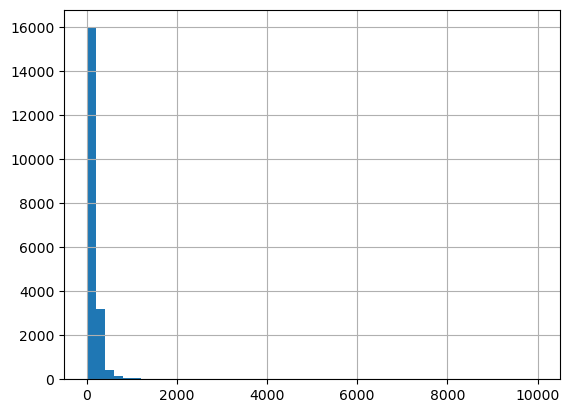

In [7]:
df["price"].hist(bins=50)

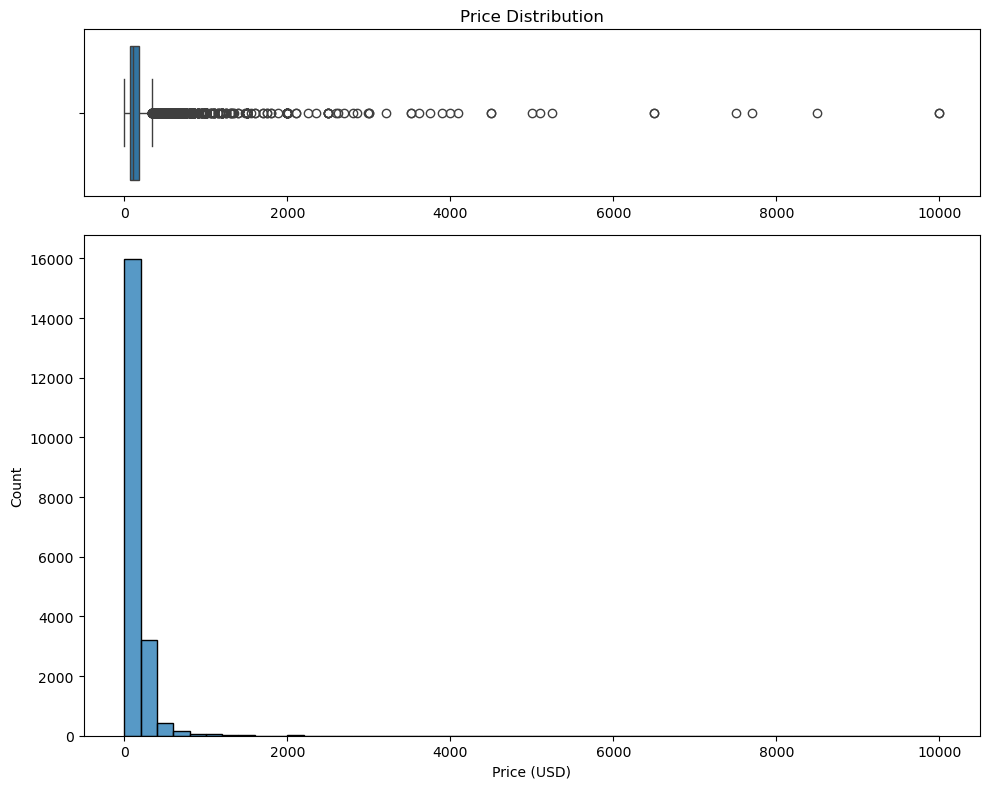

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [1, 3]})

sns.boxplot(x=df["price"], ax=axes[0])
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("")

sns.histplot(df["price"], bins=50, ax=axes[1])
axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

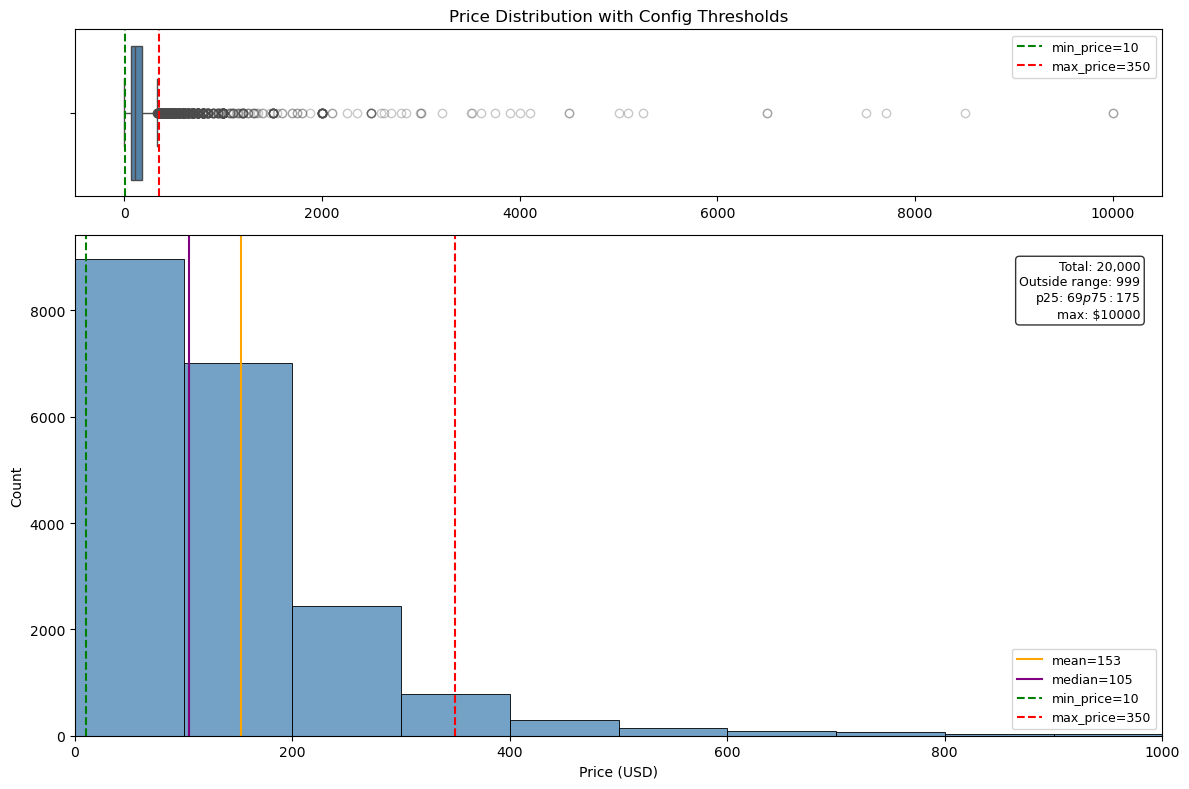

In [ ]:
min_price = 10  # config.yaml
max_price = 350  # config.yaml

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [1, 3]})

# --- Boxplot ---
sns.boxplot(x=df["price"], ax=axes[0], color="steelblue", flierprops={"alpha": 0.3})
axes[0].axvline(
    min_price,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"min_price={min_price}",
)
axes[0].axvline(
    max_price,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"max_price={max_price}",
)
axes[0].set_title("Price Distribution with Config Thresholds")
axes[0].set_xlabel("")
axes[0].legend(fontsize=9)

# --- Histogram ---
sns.histplot(df["price"], bins=100, ax=axes[1], color="steelblue")
axes[1].axvline(
    df["price"].mean(),
    color="orange",
    linestyle="-",
    linewidth=1.5,
    label=f"mean={df['price'].mean():.0f}",
)
axes[1].axvline(
    df["price"].median(),
    color="purple",
    linestyle="-",
    linewidth=1.5,
    label=f"median={df['price'].median():.0f}",
)
axes[1].axvline(
    min_price,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"min_price={min_price}",
)
axes[1].axvline(
    max_price,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"max_price={max_price}",
)
axes[1].set_xlim(0, 1000)  # zoom onde estão 95%+ dos dados
axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9)

# --- Stats annotation ---
stats = df["price"].describe()
stats_text = (
    f"Total: {len(df):,}\n"
    f"Outside range: {(~df['price'].between(min_price, max_price)).sum():,}\n"
    f"p25: ${stats['25%']:.0f}  p75: ${stats['75%']:.0f}\n"
    f"max: ${stats['max']:.0f}"
)
axes[1].text(
    0.98,
    0.95,
    stats_text,
    transform=axes[1].transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()


In [10]:
df.select_dtypes(include="number").corr()["price"].sort_values()

longitude                        -0.153573
number_of_reviews                -0.046784
reviews_per_month                -0.035664
id                                0.014750
host_id                           0.016202
latitude                          0.039562
minimum_nights                    0.045317
calculated_host_listings_count    0.052515
availability_365                  0.086792
price                             1.000000
Name: price, dtype: float64

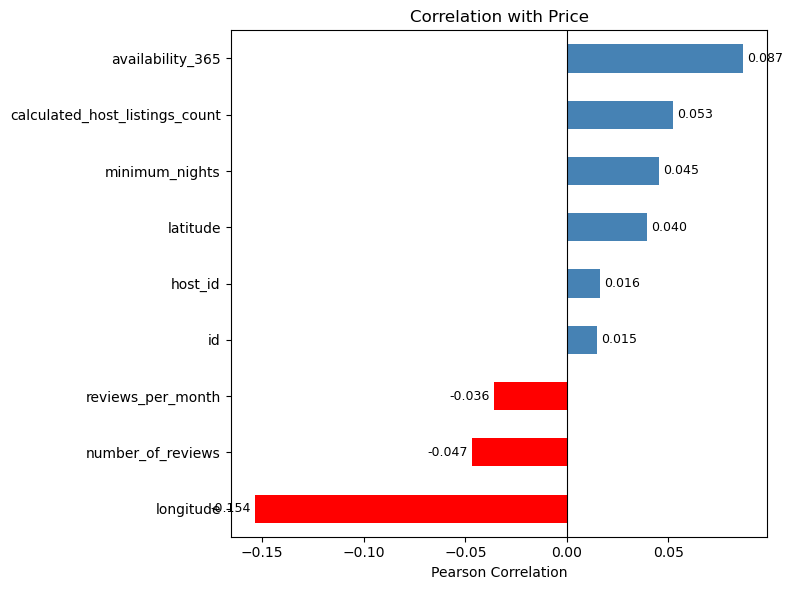

In [ ]:
corr = df.select_dtypes(include="number").corr()["price"].drop("price").sort_values()

fig, ax = plt.subplots(figsize=(8, 6))

colors = ["red" if v < 0 else "steelblue" for v in corr.values]
corr.plot(kind="barh", ax=ax, color=colors)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with Price")
ax.set_xlabel("Pearson Correlation")

for i, v in enumerate(corr.values):
    ax.text(
        v + (0.002 if v >= 0 else -0.002),
        i,
        f"{v:.3f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


## Geographic Distribution

Check that all listings fall within the expected boundaries for NYC:
- Longitude: between -74.25 and -73.50
- Latitude: between 40.5 and 41.2

Listings outside these boundaries are data entry errors or test entries that must be removed.


In [ ]:
idx_geo = df["longitude"].between(-74.25, -73.50) & df["latitude"].between(40.5, 41.2)
outside = (~idx_geo).sum()
print(f"Properties outside NYC boundaries: {outside}")
print(f"Percentage: {outside / len(df):.2%}")

# Show the outliers
df[~idx_geo][["id", "name", "latitude", "longitude", "neighbourhood_group"]].head()

## Basic Fixes

Three issues identified during EDA:

1. **Price outliers** — the distribution shows prices ranging up to $10,000, but the vast
   majority of listings are below $350. Values below $10 are likely data entry errors.
   Thresholds `min_price=10` and `max_price=350` are set in `config.yaml` and applied here
   for analysis. The `basic_cleaning` step will enforce these same limits in the pipeline.

2. **`last_review` type** — loaded as `object` (string) but represents a date.
   Must be converted to `datetime` for any time-based analysis and to avoid issues
   in downstream pipeline steps.

3. **Geographic outliers** — some listings have coordinates outside NYC proper boundaries.
   These are removed by filtering longitude between -74.25 and -73.50, and latitude
   between 40.5 and 41.2. This check is critical for model generalization.


In [ ]:
before = len(df)

# Remove price outliers
min_price = 10
max_price = 350
idx = df["price"].between(min_price, max_price)
df = df[idx].copy()

# Convert last_review to datetime
df["last_review"] = pd.to_datetime(df["last_review"])

# Remove properties outside NYC geographic boundaries
idx_geo = df["longitude"].between(-74.25, -73.50) & df["latitude"].between(40.5, 41.2)
df = df[idx_geo].copy()

print(f"Rows removed: {before - len(df):,} ({(before - len(df)) / before:.1%})")
print(f"Rows remaining: {len(df):,}")
print(f"
last_review dtype: {df['last_review'].dtype}")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19001 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              19001 non-null  int64         
 1   name                            18994 non-null  object        
 2   host_id                         19001 non-null  int64         
 3   host_name                       18993 non-null  object        
 4   neighbourhood_group             19001 non-null  object        
 5   neighbourhood                   19001 non-null  object        
 6   latitude                        19001 non-null  float64       
 7   longitude                       19001 non-null  float64       
 8   room_type                       19001 non-null  object        
 9   price                           19001 non-null  int64         
 10  minimum_nights                  19001 non-null  int64         
 11  number_

In [14]:
run.finish()

wandb: ERROR Unable to save notebook session history.
